# Online Retail Customers Segmentation
---

## 1. Problem Description

### Problem Statement
Online retail businesses generate large volumes of transaction-level data, but customer behavior is often heterogeneous and hard to interpret at scale. This creates a key challenge: how to segment customers into meaningful behavioral groups that can support targeted strategy.

### Goal
Build a **K-means clustering model** that groups customers into distinct segments based on purchase behavior patterns derived from transactional data.

The trained model will help the business:
- Identify high-value, regular, and at-risk customer groups
- Design targeted marketing and retention campaigns per segment
- Improve business decisions through interpretable customer profiles

### Features Description

| Feature | Type | Description |
|---|---|---|
| `Invoice` | Categorical | Invoice identifier |
| `StockCode` | Categorical | Product code |
| `Description` | Categorical | Product description |
| `Quantity` | Numerical (int) | Units purchased per line item |
| `InvoiceDate` | Datetime | Transaction timestamp |
| `Price` | Numerical (float) | Unit price |
| `Customer ID` | Numerical | Unique customer identifier |
| `Country` | Categorical | Customer country |

### Metrics
| Metric | Description |
| --- | --- |
| **Silhouette Score (Primary)** | Measures cluster compactness and separation; higher is better |
| **Davies-Bouldin Index** | Measures average cluster similarity; lower is better |
| **Calinski-Harabasz Index** | Ratio of between-cluster to within-cluster dispersion; higher is better |
| **Inertia (WCSS)** | Sum of squared distances to nearest centroid; lower is better |

---
## 2. IMPORT LIBRARIES

In [1]:
# ── Core ──
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import joblib

# ── Visualisation ──
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# ── Preprocessing ──
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer

# ── Dimensionality Reduction ──
from sklearn.decomposition import PCA

# ── Clustering ──
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# ── Pipeline ──
from sklearn.pipeline import Pipeline

# ── Evaluation ──
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

---
## 3. DATA LOADING & DISCOVERY

In [2]:
raw_df = pd.read_excel('../data/online_retail_II.xlsx')
print(f"Rows: {raw_df.shape[0]:,}  |  Columns: {raw_df.shape[1]}")
raw_df.head(10)

Rows: 525,461  |  Columns: 8


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [3]:
print("── Basic Info ──")
raw_df.info()

── Basic Info ──
<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 38.8+ MB


In [4]:
print("── Descriptive Statistics ──")
raw_df.describe(include='all').T

── Descriptive Statistics ──


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Invoice,525461.0,28816.0,537434.0,675.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,525461,4632,85123A,3516,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,522533,4681,WHITE HANGING HEART T-LIGHT HOLDER,3549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,525461.0,NaN,NaN,NaN,10.337667,-9600.0,1.0,3.0,10.0,19152.0,107.42411
InvoiceDate,525461,NaN,NaN,NaN,2010-06-28 11:37:36.845018,2009-12-01 07:45:00,2010-03-21 12:20:00,2010-07-06 09:51:00,2010-10-15 12:45:00,2010-12-09 20:01:00,NaN
Price,525461.0,NaN,NaN,NaN,4.688834,-53594.36,1.25,2.1,4.21,25111.09,146.126914
Customer ID,417534.0,NaN,NaN,NaN,15360.645478,12346.0,13983.0,15311.0,16799.0,18287.0,1680.811316
Country,525461,40,United Kingdom,485852,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# ── Duplicates ──
n_dup = raw_df.duplicated().sum()
print(f"Duplicated rows: {n_dup}")

# ── Null values ──
null_counts = raw_df.isnull().sum()
print(f"\nNull value counts:\n{null_counts}")

Duplicated rows: 6865

Null value counts:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [6]:
print(f"Unique Customers: {raw_df['Customer ID'].nunique():,}")
print(f"Unique Products: {raw_df['StockCode'].nunique():,}")
print(f"Unique Invoices: {raw_df['Invoice'].nunique():,}")
print(f"Countries: {raw_df['Country'].nunique():,}")
print(f"Date Range: {raw_df['InvoiceDate'].min()} to {raw_df['InvoiceDate'].max()}")

Unique Customers: 4,383
Unique Products: 4,632
Unique Invoices: 28,816
Countries: 40
Date Range: 2009-12-01 07:45:00 to 2010-12-09 20:01:00


### Data Discovery summary
- The raw dataset contains **525,461 transactions** across **8 columns** and spans from **2009-12-01** to **2010-12-09**.
- Coverage is broad: **4,383 unique customers**, **4,632 products**, **28,816 invoices**, and activity from **40 countries**.
- Key data quality issues were identified early: **6,865 duplicated rows**, **107,927 missing Customer IDs**, **2928 missing descriptions**, and negative values in transactional features like **Price** and **Quantity**.
- Most fields are complete, but missing customer identifiers are substantial and will directly affect customer-level segmentation.

---
## 4. DATA PREPROCESSING

In [7]:
df_clean = raw_df.copy()

# Remove records with missing Customer ID (can't segment without customer identifier)
df_clean = df_clean.dropna(subset=['Customer ID'])
print(f"Remaining rows after removing missing Customer ID: {len(df_clean):,} rows")

# Remove negative or zero quantities and prices
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['Price'] > 0]
print(f"Remaining rows after removing invalid prices and quantities: {len(df_clean):,} rows")

# Remove duplicated rows
df_clean = df_clean.drop_duplicates()
print(f"Remaining rows after removing duplicated rows: {len(df_clean):,} rows")

Remaining rows after removing missing Customer ID: 417,534 rows
Remaining rows after removing invalid prices and quantities: 407,664 rows
Remaining rows after removing duplicated rows: 400,916 rows


In [8]:
print(f"Number of rows dropped during cleaning: {len(raw_df) - len(df_clean):,}")
print(f"Dropped about {round((1 - (len(df_clean)/len(raw_df)))*100,2)}% of records during cleaning")

Number of rows dropped during cleaning: 124,545
Dropped about 23.7% of records during cleaning


In [9]:
# convert ID to be integer
df_clean['Customer ID'] = df_clean['Customer ID'].astype('int64')

### Data Preprocessing summary
- Cleaning reduced the dataset from **525,461** to **400,916** transactions, dropping **124,545 rows** (**23.7%**) to improve data reliability for segmentation.
- Records with missing **Customer ID** were removed first, leaving **417,534** rows (required for customer-level aggregation).
- Invalid transactional values were filtered out by keeping only **Quantity > 0** and **Price > 0**, resulting in **407,664** rows.
- Removing exact duplicate rows produced the final cleaned transactional base of **400,916** rows, then `Customer ID` was standardized to integer type for consistent downstream joins/grouping.

---
## 5. FEATURE ENGINEERING

In [10]:
fe_df = df_clean.copy()

fe_df['DayOfWeek'] = fe_df['InvoiceDate'].dt.dayofweek
fe_df['Month'] = fe_df['InvoiceDate'].dt.month
fe_df["line_amount"] = fe_df["Quantity"] * fe_df["Price"]

cust_agg = (
    fe_df.groupby("Customer ID").agg(
        Country=("Country", lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]),
        TotalSpend=("line_amount", "sum"),
        TotalQuantity=("Quantity", "sum"),
        InvoiceCount=("Invoice", "nunique"),
        UniqueProducts=("StockCode", "nunique"),
        AverageItemPrice=("Price", "mean"),
        FirstPurchase=("InvoiceDate", "min"),
        LastPurchase=("InvoiceDate", "max"),
        MostActiveDay=("DayOfWeek", lambda x: x.mode().iat[0] if not x.mode().empty else x.iloc[0]),
        MostActiveMonth=("Month", lambda x: x.mode().iat[0] if not x.mode().empty else x.iloc[0]),
    ).reset_index()
)

cust_agg["RecencyDays"] = (fe_df["InvoiceDate"].max() - cust_agg["LastPurchase"]).dt.days

cust_agg["TenureDays"] = (cust_agg["LastPurchase"] - cust_agg["FirstPurchase"]).dt.days

cust_agg['ActiveMonths'] = np.ceil((cust_agg['TenureDays'] + 1) / 30).clip(lower=1)

cust_agg["AvgBasketValue"] = cust_agg["TotalSpend"] / cust_agg["InvoiceCount"]

cust_agg["SpendPerProduct"] = cust_agg["TotalSpend"] / cust_agg["UniqueProducts"]

cust_agg["QuantityPerInvoice"] = cust_agg["TotalQuantity"] / cust_agg["InvoiceCount"]

cust_agg['InvoicePerMonth'] = cust_agg['InvoiceCount'] / cust_agg['ActiveMonths']

cust_agg['IsOneTransactionCustomer'] = (cust_agg['InvoiceCount'] == 1).astype(int)

In [11]:
cust_agg

,Customer ID,Country,TotalSpend,TotalQuantity,InvoiceCount,UniqueProducts,AverageItemPrice,FirstPurchase,LastPurchase,MostActiveDay,MostActiveMonth,RecencyDays,TenureDays,ActiveMonths,AvgBasketValue,SpendPerProduct,QuantityPerInvoice,InvoicePerMonth,IsOneTransactionCustomer
0,12346,United Kingdom,372.86,70,11,26,6.253333,2009-12-14 08:34:00,2010-06-28 13:53:00,0,6,164,196,7.0,33.896364,14.340769,6.363636,1.571429,0
1,12347,Iceland,1323.32,828,2,70,2.295070,2010-10-31 14:20:00,2010-12-07 14:57:00,6,10,2,37,2.0,661.660000,18.904571,414.000000,1.000000,0
2,12348,Finland,222.16,373,1,20,0.719500,2010-09-27 14:59:00,2010-09-27 14:59:00,0,9,73,0,1.0,222.160000,11.108000,373.000000,1.000000,1
3,12349,Italy,2671.14,993,3,90,8.581765,2010-04-29 13:20:00,2010-10-28 08:23:00,3,10,42,181,7.0,890.380000,29.679333,331.000000,0.428571,0
4,12351,Unspecified,300.93,261,1,21,2.355238,2010-11-29 15:23:00,2010-11-29 15:23:00,0,11,10,0,1.0,300.930000,14.330000,261.000000,1.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4307,18283,United Kingdom,619.37,322,6,158,2.199401,2010-02-19 17:16:00,2010-11-22 15:30:00,0,3,17,275,10.0,103.228333,3.920063,53.666667,0.600000,0
4308,18284,United Kingdom,461.68,494,1,28,3.253214,2010-10-04 11:33:00,2010-10-04 11:33:00,0,10,66,0,1.0,461.680000,16.488571,494.000000,1.000000,1
4309,18285,United Kingdom,427.00,145,1,12,8.350000,2010-02-17 10:24:00,2010-02-17 10:24:00,2,2,295,0,1.0,427.000000,35.583333,145.000000,1.000000,1
4310,18286,United Kingdom,1296.43,608,2,67,4.273134,2009-12-16 10:45:00,2010-08-20 11:57:00,4,8,111,247,9.0,648.215000,19.349701,304.000000,0.222222,0


### Feature Engineering summary
- Transactions were transformed into a **customer-level analytical table** (`cust_agg`) for segmentation, reducing granularity from invoice lines to one row per customer.
- The engineered dataset combines monetary, frequency, and product-diversity metrics (e.g., **TotalSpend**, **InvoiceCount**, **UniqueProducts**) with behavioral and temporal features.
- Additional features capture lifecycle and shopping behavior: **RecencyDays**, **TenureDays**, **ActiveMonths**, **AvgBasketValue**, **SpendPerProduct**, **QuantityPerInvoice**, **InvoicePerMonth**, and **IsOneTransactionCustomer**.

### DATA PREPROCESSING CONT...

Apply 99th percentile capping to reduce the effect of extreme values.
 This keeps all customers while limiting outliers that can distort K-Means clustering.

In [12]:
numeric_features_for_cap = cust_agg.select_dtypes("number").columns
numeric_features_for_cap = numeric_features_for_cap.drop(['Customer ID', 'MostActiveDay', 'MostActiveMonth', 'IsOneTransactionCustomer'])

cust_agg_capped = cust_agg.copy()
cap_summary = []

for f in numeric_features_for_cap:
    upper = cust_agg_capped[f].quantile(0.99)

    original = cust_agg_capped[f].copy()
    cust_agg_capped[f] = cust_agg_capped[f].clip(upper=upper)
    n_capped = int((original != cust_agg_capped[f]).sum())

    cap_summary.append({
        'feature': f,
        'n_capped': n_capped
    })

cap_summary_df = pd.DataFrame(cap_summary).sort_values('n_capped', ascending=False)
display(cap_summary_df)

,feature,n_capped
0,TotalSpend,44
1,TotalQuantity,44
3,UniqueProducts,44
4,AverageItemPrice,44
8,AvgBasketValue,44
9,SpendPerProduct,44
10,QuantityPerInvoice,44
11,InvoicePerMonth,44
2,InvoiceCount,43
6,TenureDays,41


---
## 6. EXPLORATORY DATA ANALYSIS (EDA)

### Setup for EDA

In [13]:
plot_df = cust_agg_capped.copy()

# Treat these as categorical for EDA visualization
plot_df['MostActiveDay'] = plot_df['MostActiveDay'].map({
    0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'})

plot_df['MostActiveMonth'] = plot_df['MostActiveMonth'].map({
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'})

numeric_features = plot_df.select_dtypes(include=["number"]).columns.drop(['Customer ID'])
categorical_features = plot_df.select_dtypes(include=["object", "category"]).columns

### Univariate Analysis - Categorical Features

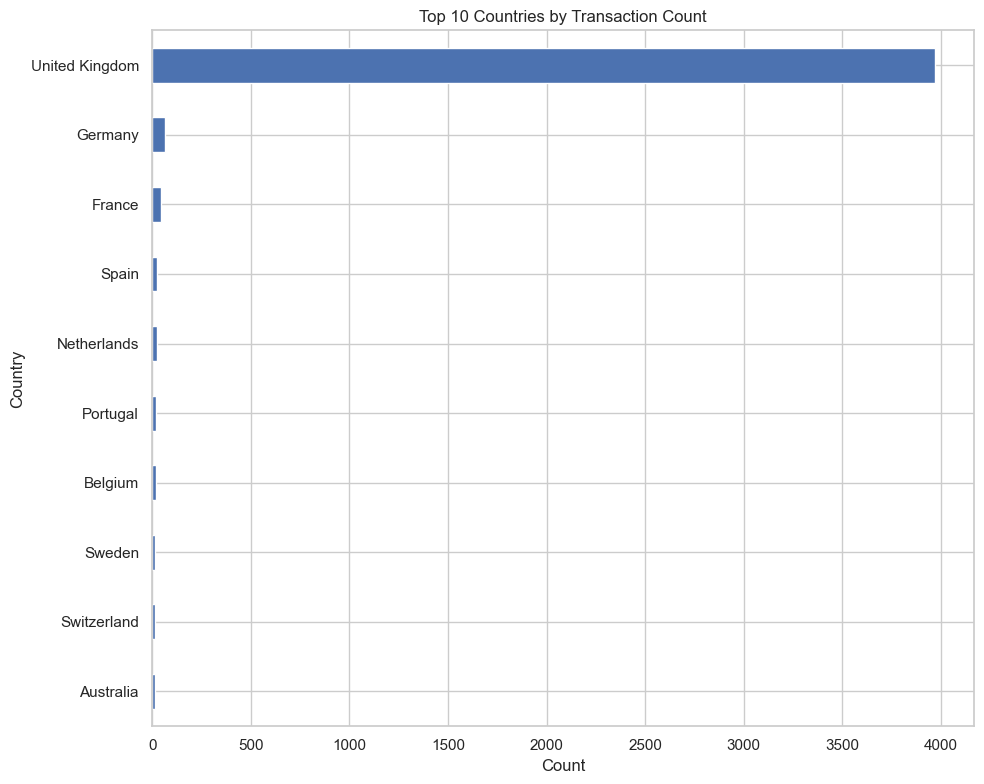

In [14]:
plt.figure(figsize=(10, 8))
country_counts = plot_df['Country'].value_counts().head(10)
country_counts.plot(kind='barh')
plt.title('Top 10 Countries by Transaction Count')
plt.xlabel('Count')
plt.ylabel('Country')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

- The customer base is highly concentrated geographically: **United Kingdom = 3,969 customers (92.05%)**, followed by **Germany = 67 (1.55%)** and **France = 47 (1.09%)**; each remaining country contributes under 1% individually.

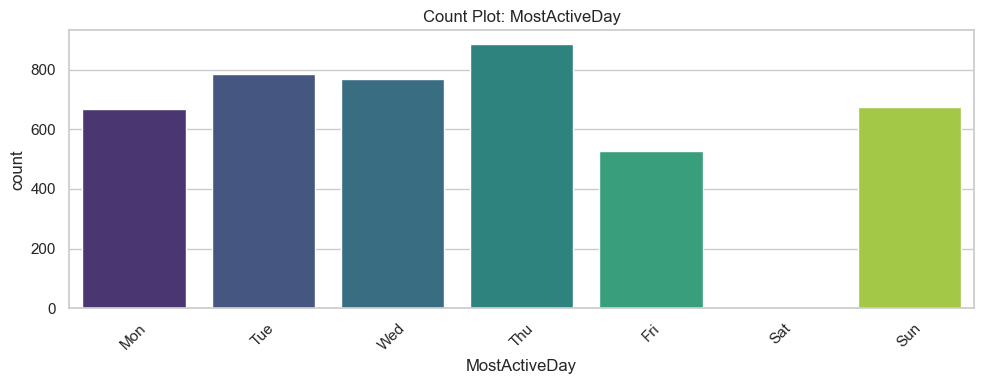

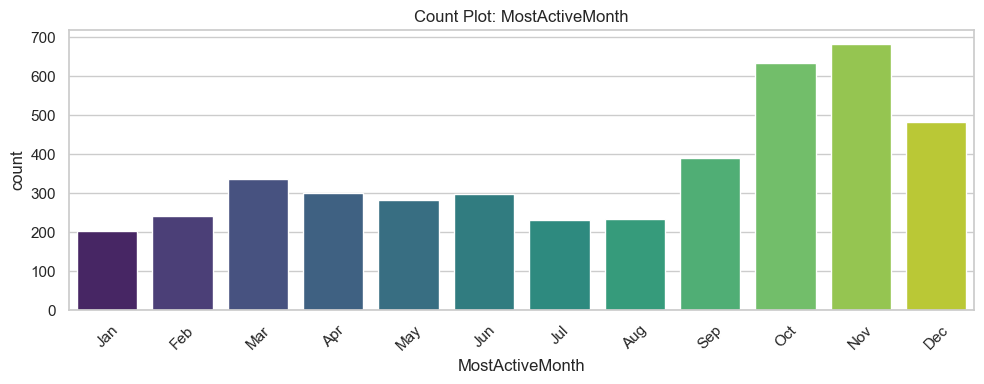

In [15]:
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
orders = {'MostActiveDay': day_order, 'MostActiveMonth': month_order}

for c in ["MostActiveDay", "MostActiveMonth"]:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=plot_df, x=c, order=orders[c], palette='viridis')
    plt.title(f'Count Plot: {c}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

- The most active shopping day is **Thursday (887 customers, 20.57%)**; **Saturday is inactive**.
- Monthly activity peaks in **November (683, 15.84%)** and **October (633, 14.68%)**, with **December (482, 11.18%)** also elevated, indicating a strong Q4 seasonal pattern.

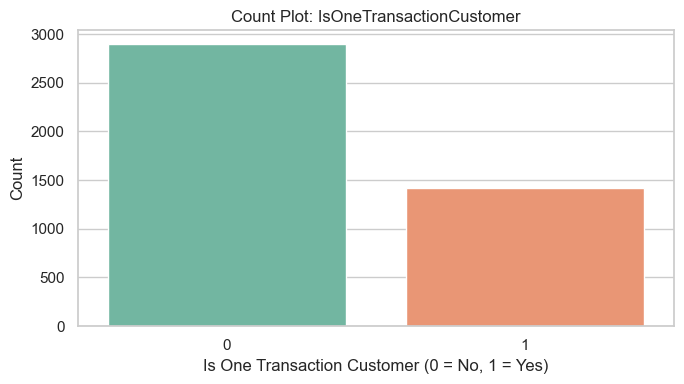

In [16]:
plt.figure(figsize=(7, 4))
sns.countplot(data=plot_df, x='IsOneTransactionCustomer', palette='Set2')
plt.title('Count Plot: IsOneTransactionCustomer')
plt.xlabel('Is One Transaction Customer (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

- The count plot indicates that customers with **more than one transaction** are **the larger group**.

### Univariate Analysis - Numerical Features

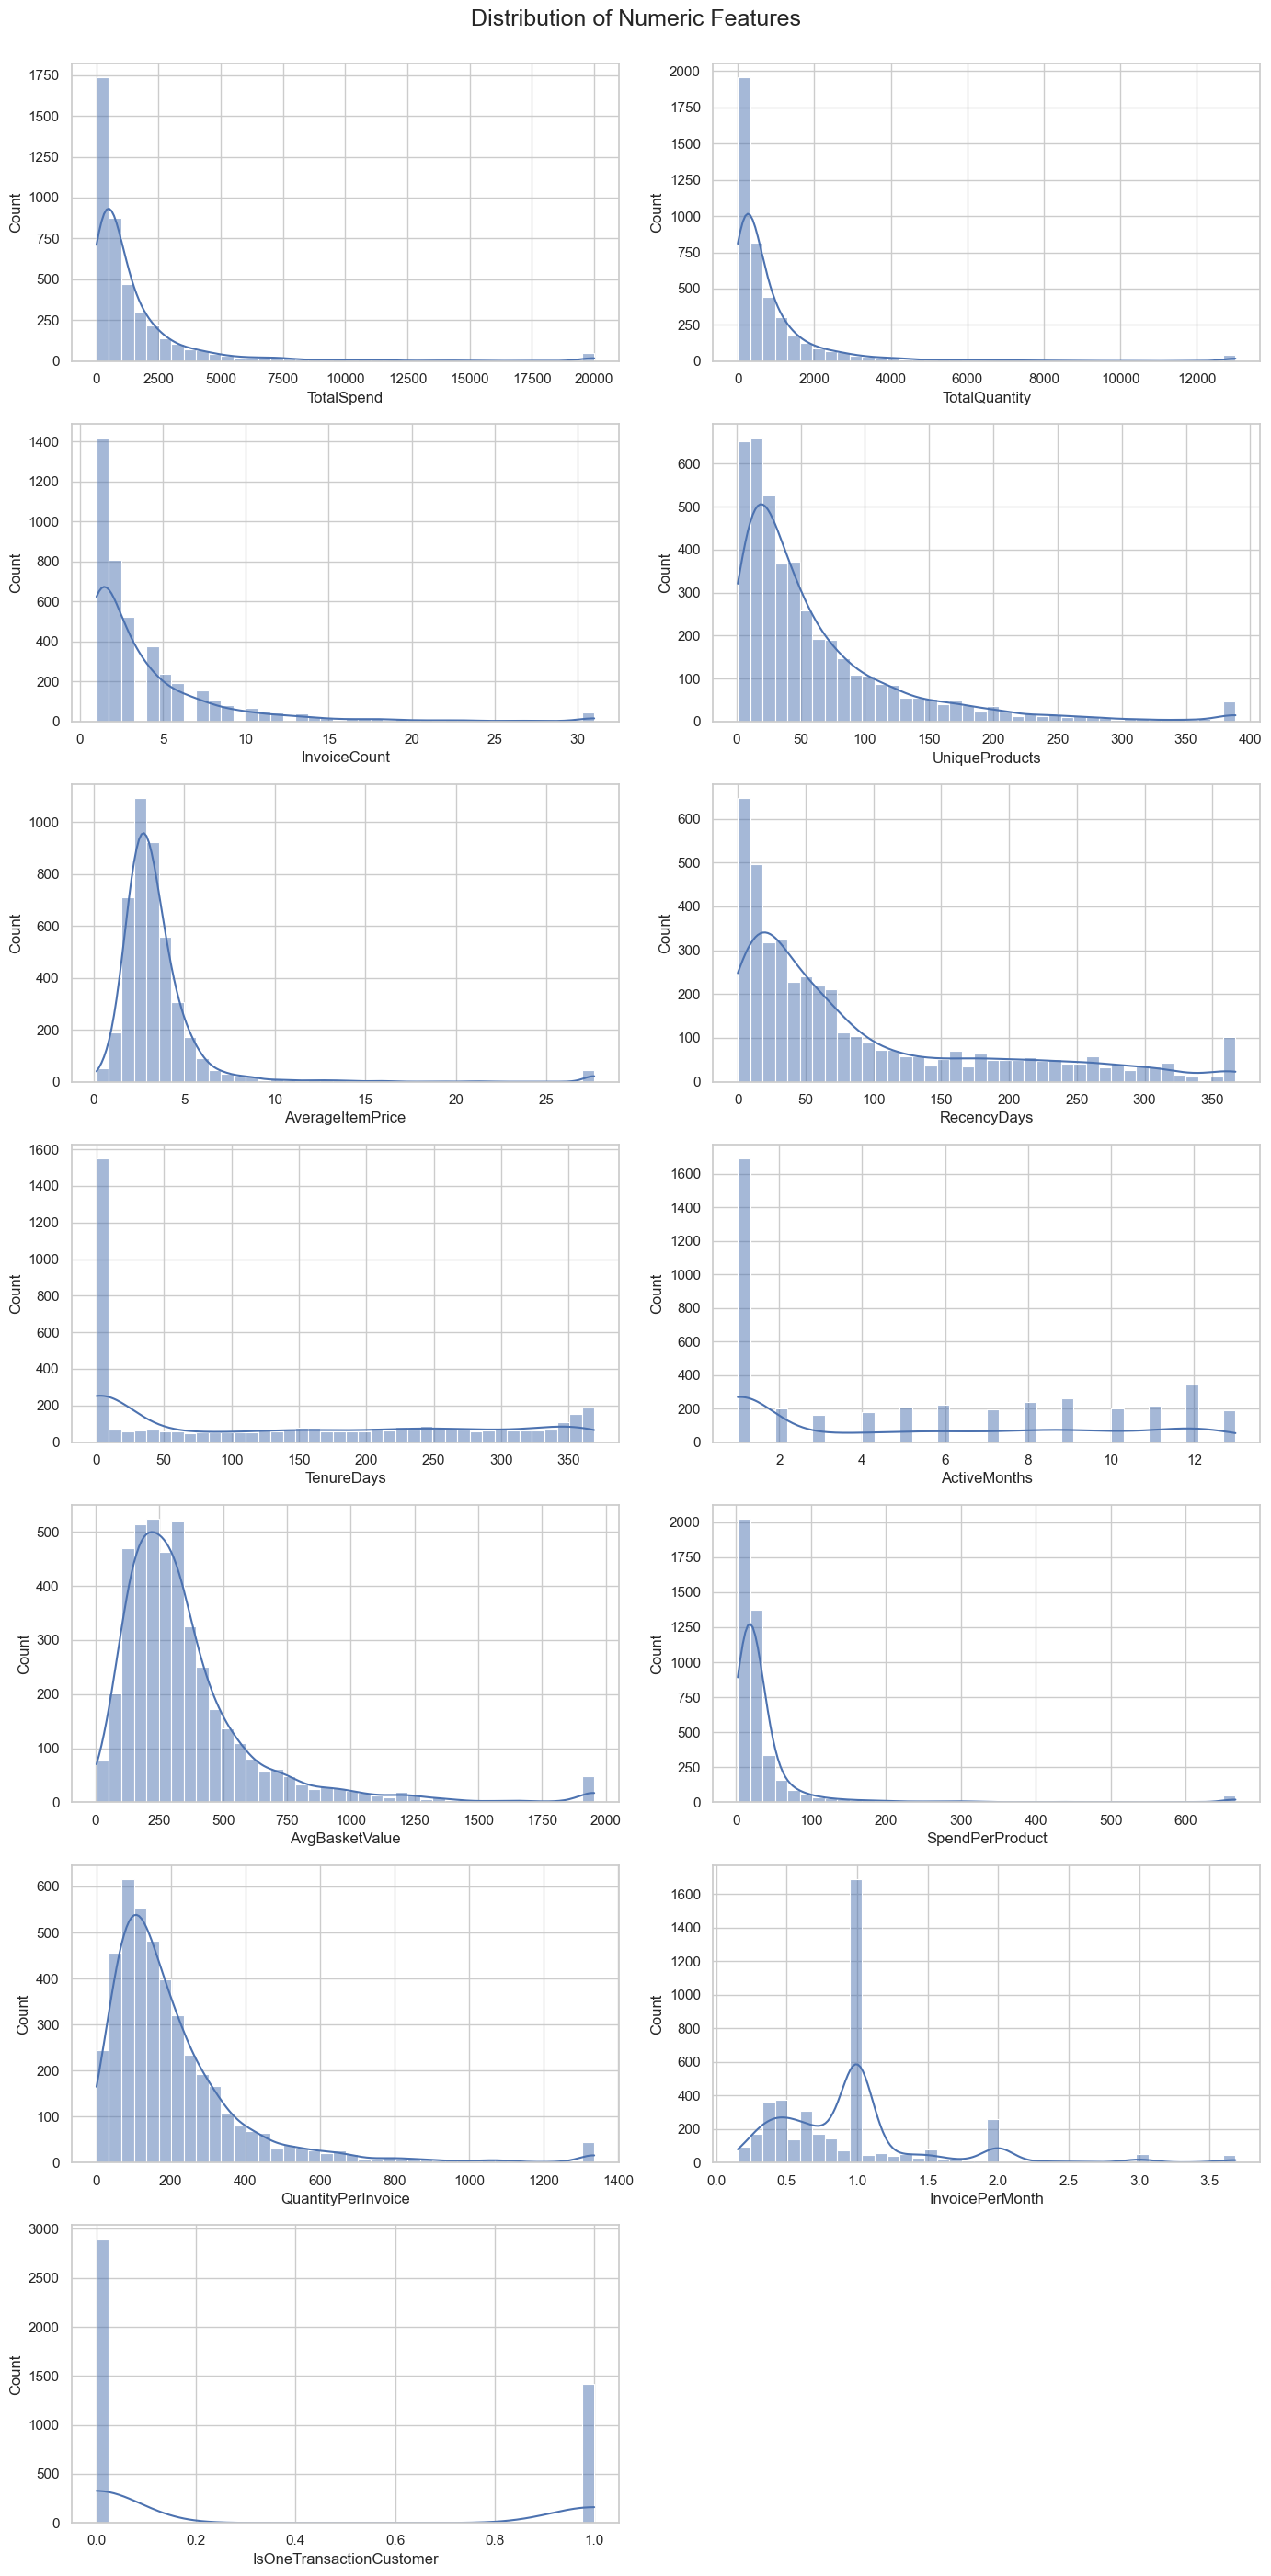

In [17]:
n = len(numeric_features)
cols = 2
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, f in enumerate(numeric_features):
    ax = axes[i]
    sns.histplot(plot_df[f], kde=True, ax=ax, bins=40)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle("Distribution of Numeric Features", fontsize=18, y=1)
plt.tight_layout()
plt.show()

In [18]:
skew_kurt = pd.DataFrame({
    'feature': numeric_features,
    'skewness': [plot_df[f].skew() for f in numeric_features],
    'kurtosis': [plot_df[f].kurtosis() for f in numeric_features]
})
skew_kurt['highly_skewed'] = skew_kurt['skewness'].abs() > 1

display(skew_kurt.sort_values('skewness', key=lambda s: s.abs(), ascending=False))

,feature,skewness,kurtosis,highly_skewed
4,AverageItemPrice,5.807840,41.539709,True
9,SpendPerProduct,5.535414,33.112517,True
1,TotalQuantity,4.606036,25.406860,True
0,TotalSpend,4.206626,20.800255,True
2,InvoiceCount,3.060510,11.470949,True
10,QuantityPerInvoice,2.893248,11.044339,True
8,AvgBasketValue,2.772294,10.100411,True
3,UniqueProducts,2.290482,6.223801,True
11,InvoicePerMonth,2.001084,5.625183,True
5,RecencyDays,1.279125,0.586986,True


### Bivariate Analysis - Numerical vs Numerical

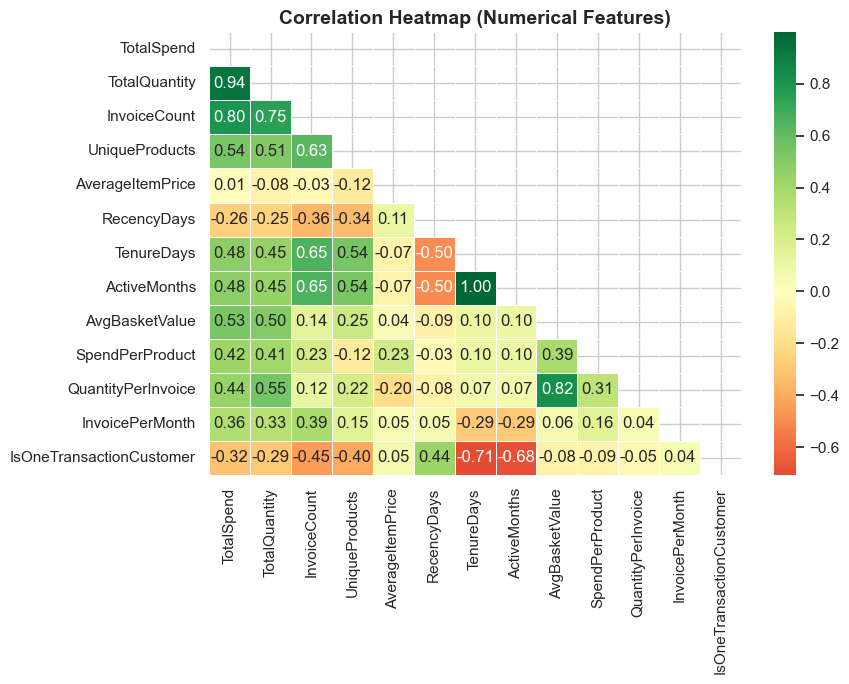

⚠️ MULTICOLLINEARITY WARNING (|r| > 0.85):
   TotalSpend <-> TotalQuantity  (r = 0.935)
   TenureDays <-> ActiveMonths  (r = 0.998)


In [19]:
# Correlation analysis
corr = plot_df[numeric_features].corr()

# Heatmap with upper triangle mask
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Correlation Heatmap (Numerical Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Multicollinearity warning
THRESHOLD = 0.85
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > THRESHOLD:
            high_corr.append((corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 3)))
if high_corr:
    print(f"⚠️ MULTICOLLINEARITY WARNING (|r| > {THRESHOLD}):")
    for a, b, r in high_corr:
        print(f"   {a} <-> {b}  (r = {r})")
else:
    print("✅ No severe multicollinearity detected")

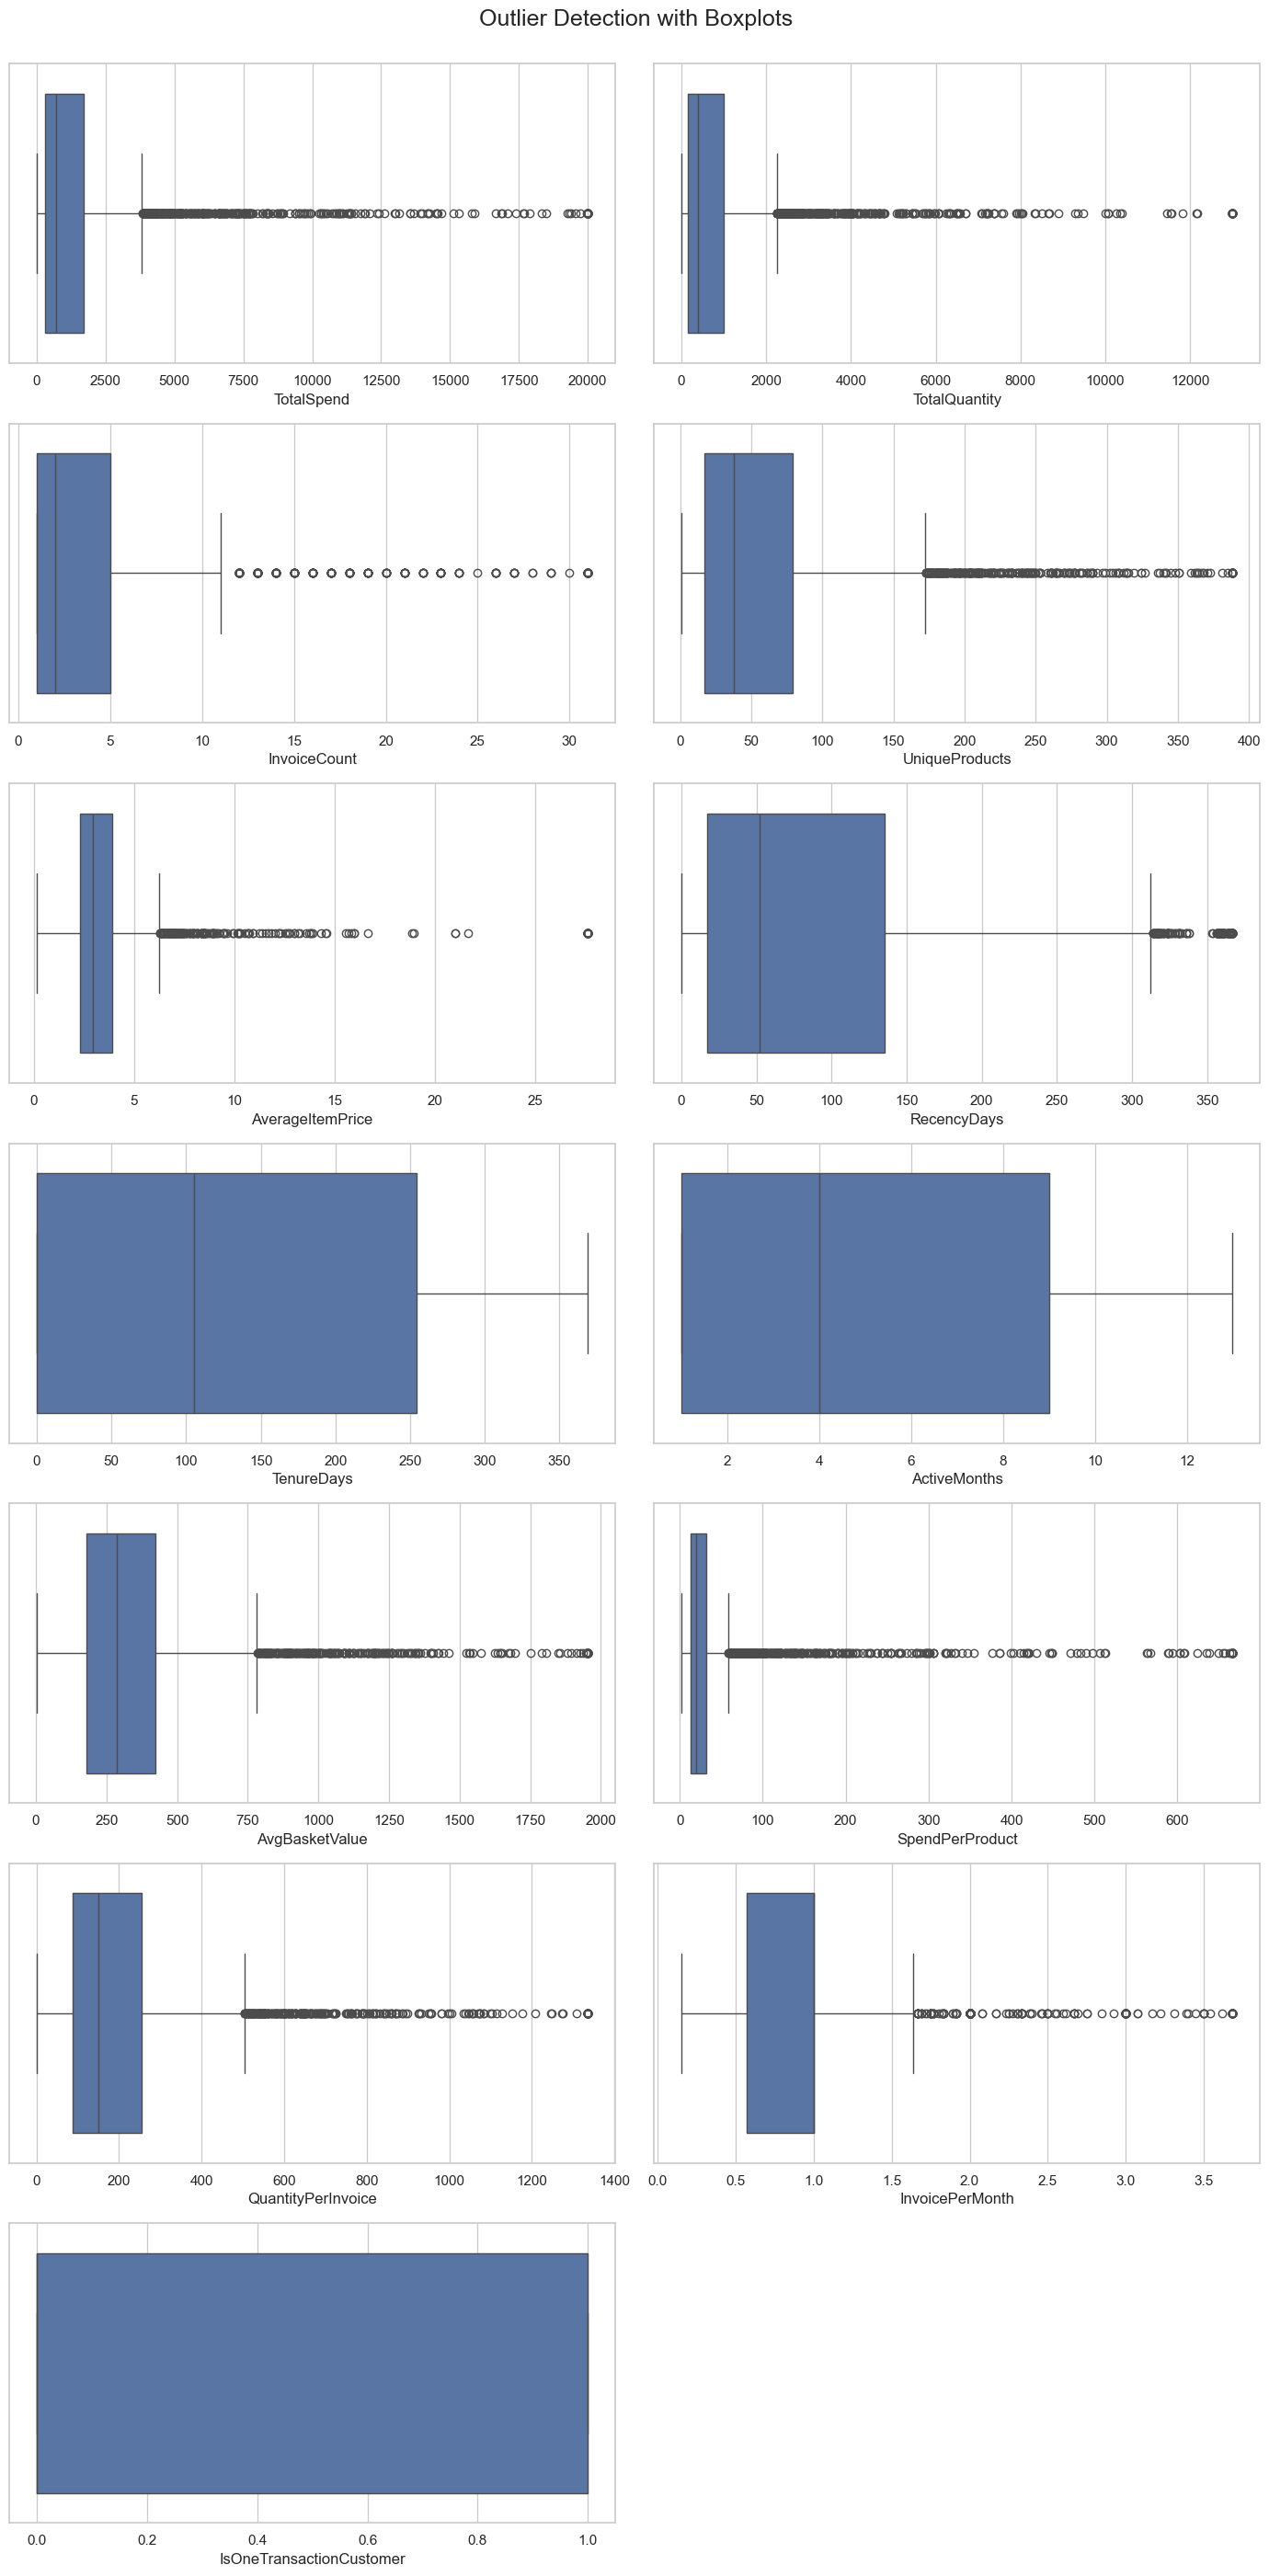

In [20]:
# Boxplots to detect outliers
fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, f in enumerate(numeric_features):
    sns.boxplot(x=plot_df[f], ax=axes[i])

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Outlier Detection with Boxplots', fontsize=18, y=1)
plt.tight_layout()
plt.show()

### EDA summary
- These patterns suggest segments are likely influenced by UK-dominant demand, mid-week purchasing behavior, and year-end seasonality.
- Distribution plots and skewness diagnostics show strong right-skew in multiple monetary/quantity features.
- Correlation analysis surfaced strong multicollinearity: **TotalSpend–TotalQuantity (0.935)** and **TenureDays–ActiveMonths (0.998)**.
- Boxplots confirm remaining outlier influence after feature engineering.

## DATA PREPROCESSING CONT...

In [21]:
# Log transform on highly skewed features after capping
skew_before = cust_agg_capped[numeric_features].skew()
high_skew_features = skew_before[skew_before.abs() > 1].index.tolist()

log_features_df = pd.DataFrame(index=cust_agg_capped.index)
for f in high_skew_features:
    log_features_df[f'{f}_log'] = np.log1p(cust_agg_capped[f])

skew_after_map = {
    f: log_features_df[f'{f}_log'].skew() if f in high_skew_features else np.nan for f in numeric_features
}

skew_compare = pd.DataFrame({
    'feature': numeric_features,
    'skew_before': [skew_before[f] for f in numeric_features],
    'skew_after_log': [skew_after_map[f] for f in numeric_features],
    'log_feature': [f'{f}_log' if f in high_skew_features else None for f in numeric_features],
})

display(skew_compare.sort_values('skew_before', key=lambda s: s.abs(), ascending=False))

,feature,skew_before,skew_after_log,log_feature
4,AverageItemPrice,5.807840,1.463987,AverageItemPrice_log
9,SpendPerProduct,5.535414,1.158141,SpendPerProduct_log
1,TotalQuantity,4.606036,-0.339910,TotalQuantity_log
0,TotalSpend,4.206626,0.114774,TotalSpend_log
2,InvoiceCount,3.060510,0.931347,InvoiceCount_log
10,QuantityPerInvoice,2.893248,-0.978258,QuantityPerInvoice_log
8,AvgBasketValue,2.772294,-0.320195,AvgBasketValue_log
3,UniqueProducts,2.290482,-0.375038,UniqueProducts_log
11,InvoicePerMonth,2.001084,0.840541,InvoicePerMonth_log
5,RecencyDays,1.279125,-0.614622,RecencyDays_log


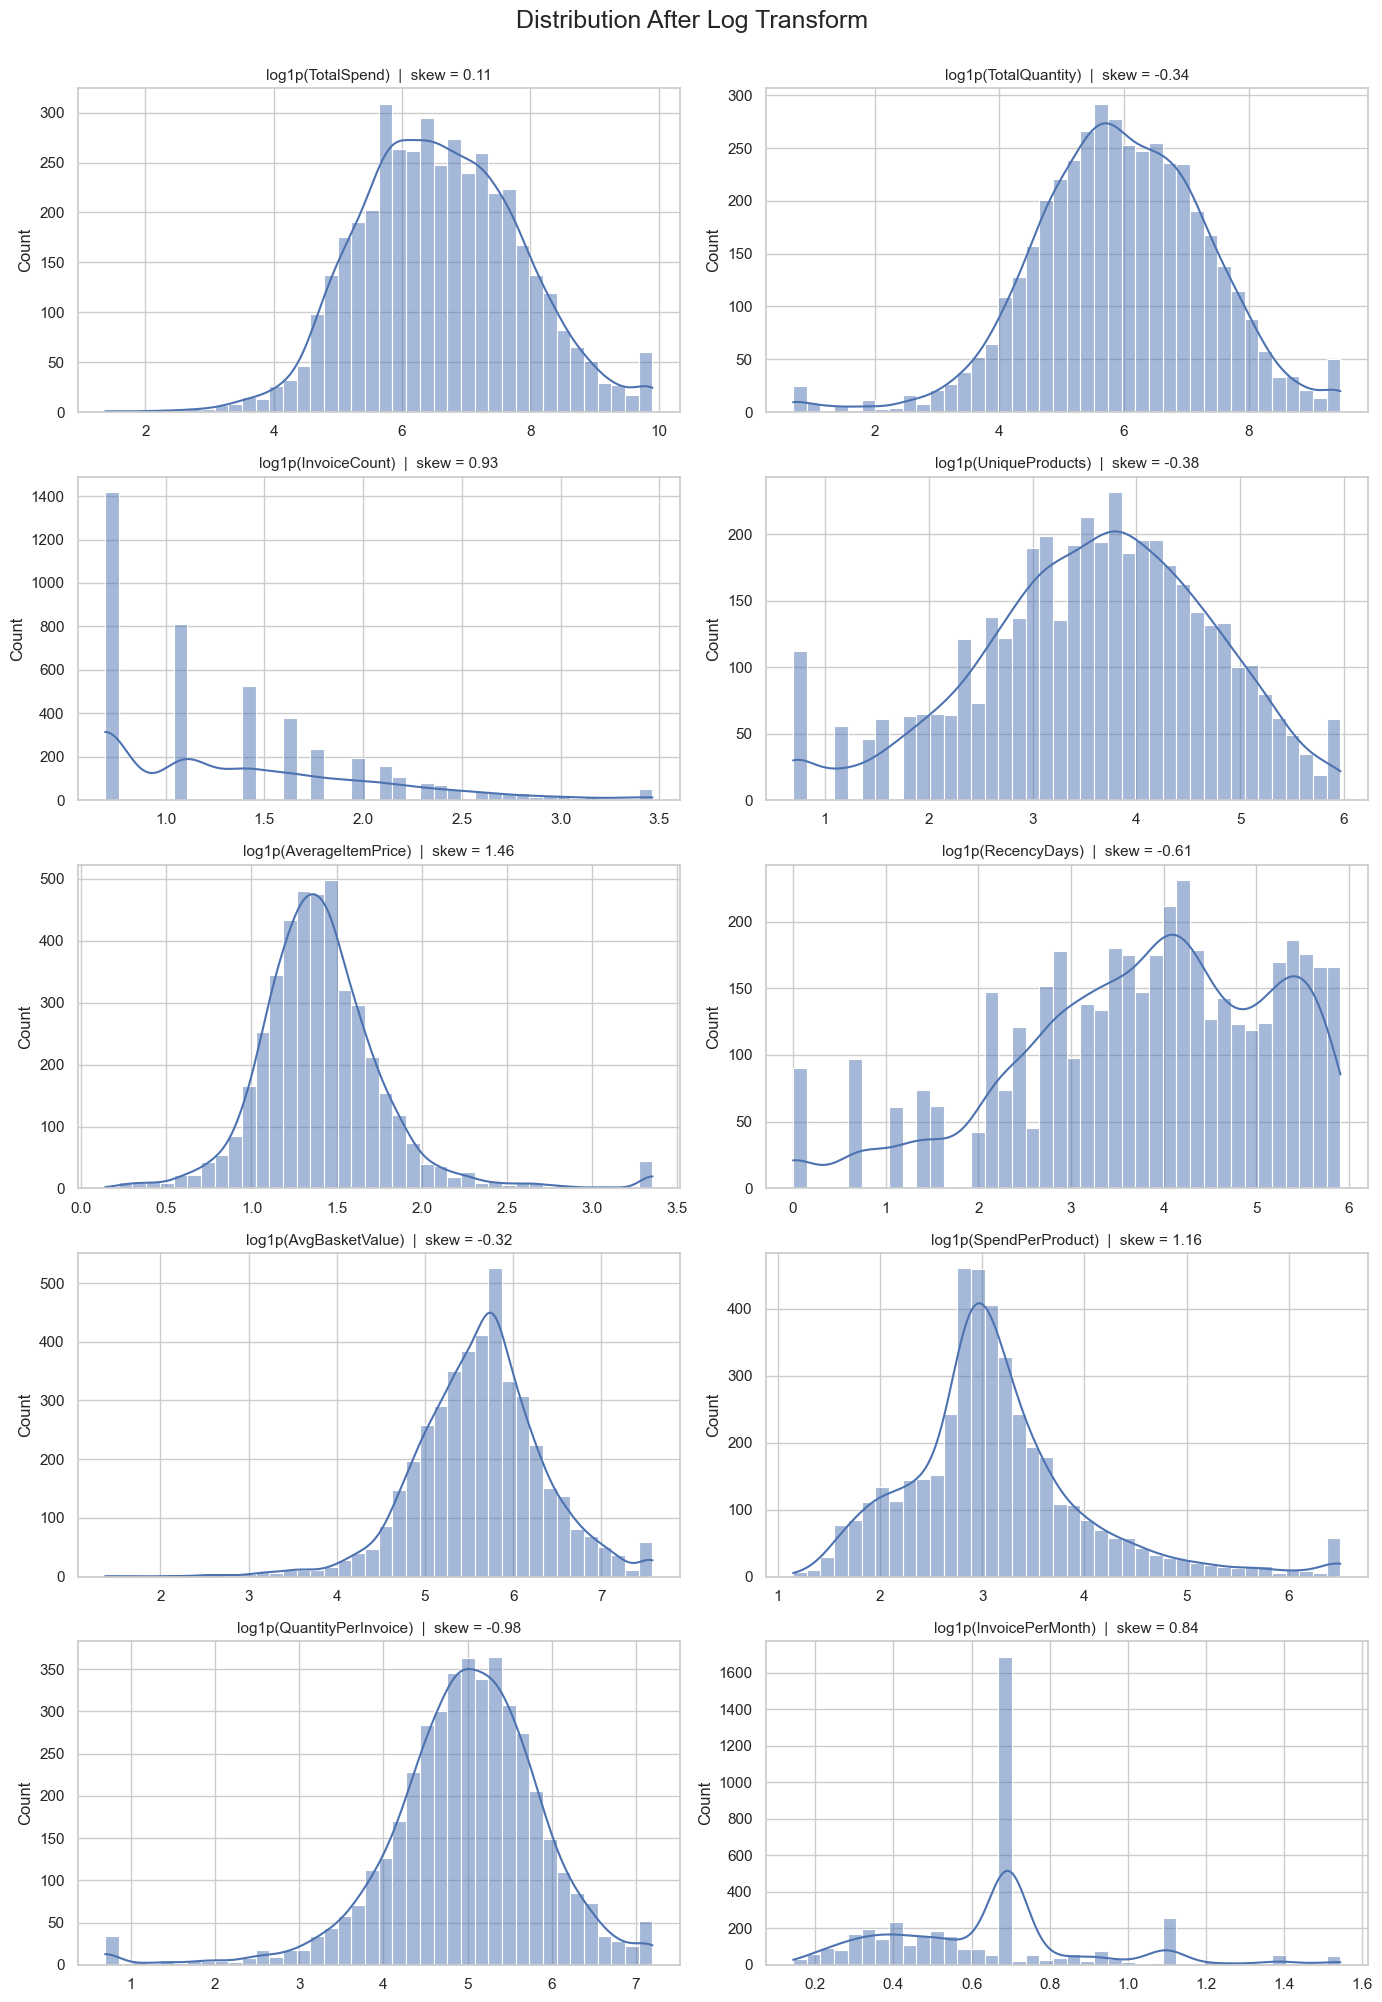

In [22]:
n = len(high_skew_features)
cols = 2
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, f in enumerate(high_skew_features):
    ax = axes[i]
    sns.histplot(log_features_df[f'{f}_log'], kde=True, ax=ax, bins=40)
    ax.set_title(f'log1p({f})  |  skew = {skew_after_map[f]:.2f}', fontsize=11)
    ax.set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle("Distribution After Log Transform", fontsize=18, y=1)
plt.tight_layout()
plt.show()

---
### Selected Features for Modeling

In [23]:
# Highly correlated pairs visible from heatmap (> 0.85):
# TotalQuantity  ↔ TotalSpend   → 0.935
# ActiveMonths   ↔ TenureDays   → 0.998

drop_features_collinearity = {'TotalQuantity', 'ActiveMonths'}
drop_features_explicit = {'Country', 'MostActiveDay', 'MostActiveMonth'}  # explicit modeling decision
drop_features = drop_features_collinearity | drop_features_explicit

model_feature_candidates = [
    c for c in cust_agg.select_dtypes(include=['number']).columns
    if c != 'Customer ID'
]
selected_features = [f for f in model_feature_candidates if f not in drop_features]

print('Dropped due to high collinearity:', sorted(drop_features_collinearity))
print('\nDropped by explicit modeling decision:', sorted(drop_features_explicit))
print('\nSelected features for modeling:', selected_features)

Dropped due to high collinearity: ['ActiveMonths', 'TotalQuantity']

Dropped by explicit modeling decision: ['Country', 'MostActiveDay', 'MostActiveMonth']

Selected features for modeling: ['TotalSpend', 'InvoiceCount', 'UniqueProducts', 'AverageItemPrice', 'RecencyDays', 'TenureDays', 'AvgBasketValue', 'SpendPerProduct', 'QuantityPerInvoice', 'InvoicePerMonth', 'IsOneTransactionCustomer']


---
## 7. PREPROCESSING PIPELINE

In [24]:
X_model = cust_agg[selected_features].copy()

caps = {c: float(X_model[c].quantile(0.99)) for c in selected_features}
def quantile_cap(X):
    X_df = X.copy()
    for c, upper in caps.items():
        X_df[c] = X_df[c].clip(upper=upper)
    return X_df

model_log_features = [f for f in selected_features if f in high_skew_features]
def apply_log_transform(X):
    X_df = X.copy()
    for c in model_log_features:
        X_df[c] = np.log1p(np.clip(X_df[c], a_min=0, a_max=None))
    return X_df

preprocess_pipeline = Pipeline(steps=[
    ('capper',  FunctionTransformer(quantile_cap)),
    ('apply_log_transform',   FunctionTransformer(apply_log_transform)),
    ('scaler',  StandardScaler()),
])

preprocess_pipeline.fit(X_model)

Pipeline(steps=[('capper',
                 FunctionTransformer(func=<function quantile_cap at 0x0000020F51CC3420>)),
                ('apply_log_transform',
                 FunctionTransformer(func=<function apply_log_transform at 0x0000020F59D38360>)),
                ('scaler', StandardScaler())])

---
## 8. K-Means Clustering

#### DETERMINING OPTIMAL NUMBER OF CLUSTERS (k)

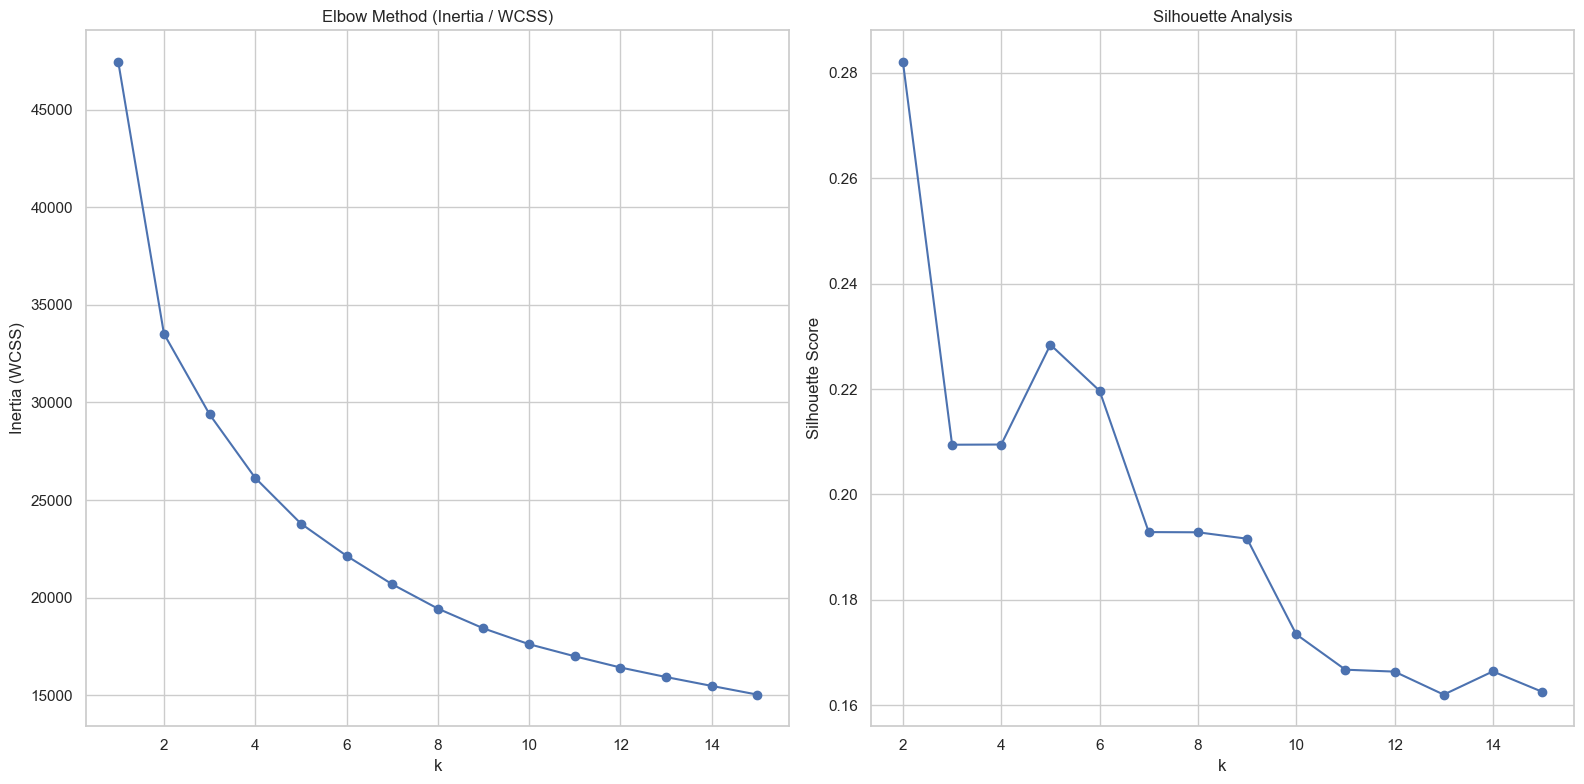

In [25]:
k_values_inertia = list(range(1, 16))
k_values_metrics = list(range(2, 16))
inertias = []
sil_scores = []

X_for_k_search = preprocess_pipeline.transform(X_model)

for k in k_values_inertia:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_for_k_search)
    inertias.append(km.inertia_)

for k in k_values_metrics:
    labels = KMeans(n_clusters=k, random_state=42, n_init=20).fit_predict(X_for_k_search)
    sil_scores.append(silhouette_score(X_for_k_search, labels))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].plot(k_values_inertia, inertias, marker='o')
axes[0].set_title('Elbow Method (Inertia / WCSS)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia (WCSS)')

axes[1].plot(k_values_metrics, sil_scores, marker='o')
axes[1].set_title('Silhouette Analysis')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

#### MODEL TRAINING

why k = 5:
- Although k = 2 achieved the highest Silhouette Score, splitting customers into only two groups is too broad and does not capture meaningful differences in customer behavior. It would limit the ability to identify practical segments such as loyal customers, high-value customers, inactive customers, or emerging regulars.

- On the other hand, k = 5 achieved one of the strongest Silhouette scores after k = 2, meaning cluster separation is still reasonably good while offering more useful segmentation depth.

- In addition, the Elbow Method shows the bending point around k = 4 to k = 6, making k = 5 a strong candidate within the optimal range where adding more clusters gives diminishing returns.

- Overall, k = 5 creates more actionable customer segments while maintaining solid clustering performance.

In [26]:
k = 5
kmeans_pipeline = Pipeline(steps=[
    ('preprocess', preprocess_pipeline),
    ('kmeans', KMeans(n_clusters=k, random_state=42)),
])

cluster_labels = kmeans_pipeline.fit_predict(X_model)
X_kmeans = kmeans_pipeline.named_steps['preprocess'].transform(X_model)

train_metrics = {
    'k': k,
    'inertia': round(kmeans_pipeline.named_steps['kmeans'].inertia_, 4),
    'silhouette': round(silhouette_score(X_kmeans, cluster_labels), 4),
    'davies_bouldin': round(davies_bouldin_score(X_kmeans, cluster_labels), 4),
    'calinski_harabasz': round(calinski_harabasz_score(X_kmeans, cluster_labels), 4)
}

metrics_df = pd.DataFrame([train_metrics])
display(metrics_df)

cluster_size = (pd.Series(cluster_labels, name='Cluster').value_counts().sort_index().rename('Customers').to_frame())
cluster_size['Share(%)'] = (cluster_size['Customers'] / cluster_size['Customers'].sum() * 100).round(2)
display(cluster_size)

,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,5,23798.2172,0.2284,1.5095,1069.3102


,Customers,Share(%)
Cluster,,
0,820,19.02
1,368,8.53
2,553,12.82
3,1157,26.83
4,1414,32.79


#### PCA CLUSTER VISUALIZATION (2D & 3D)

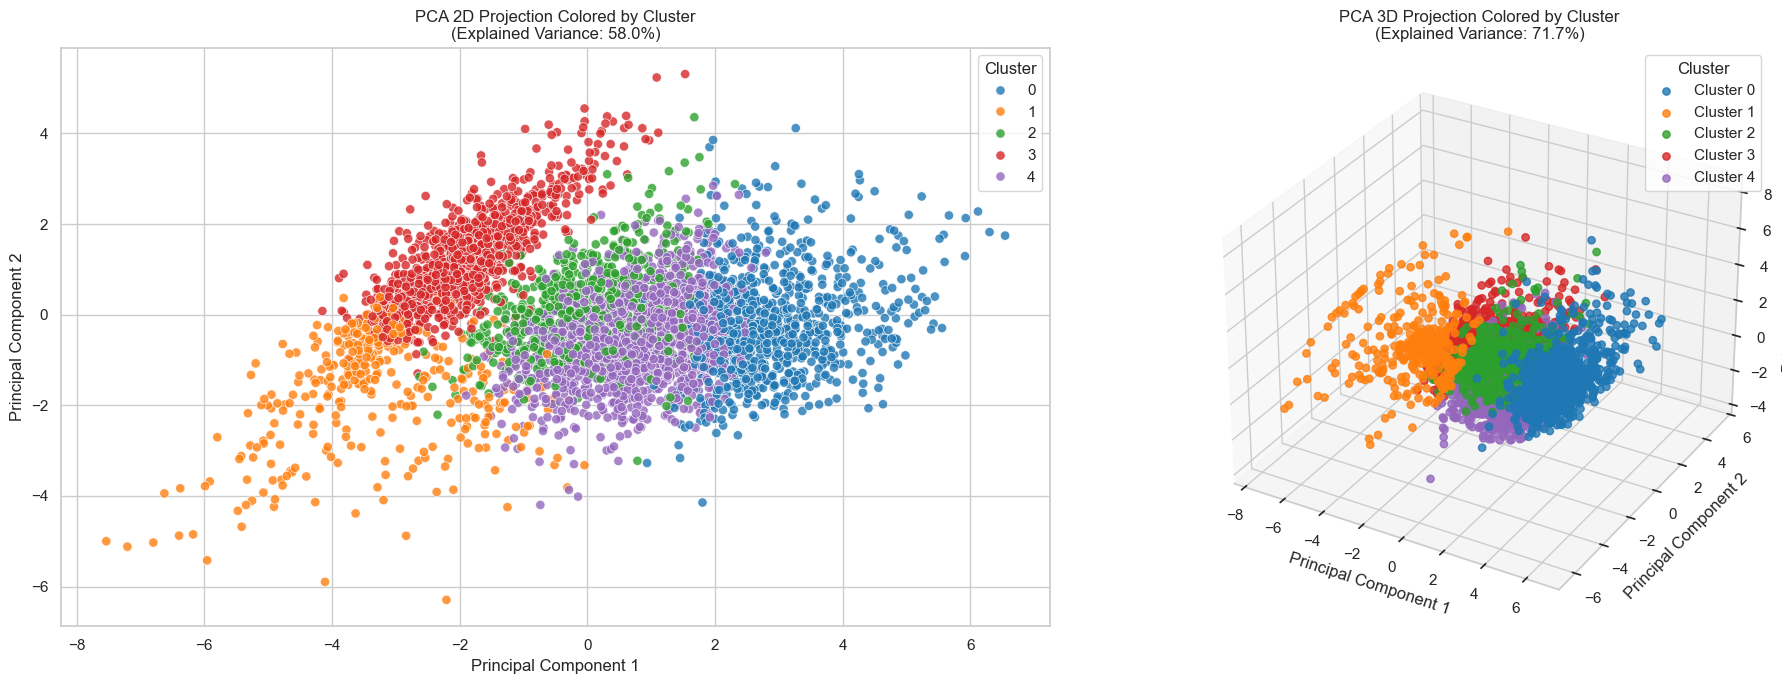

In [27]:
fig = plt.figure(figsize=(20, 7))

# ── PCA 2D ──
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_kmeans)
pca_2d_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
pca_2d_df['Cluster'] = cluster_labels

ax1 = fig.add_subplot(1, 2, 1)
sns.scatterplot(
    data=pca_2d_df,
    x='PC1', y='PC2',
    hue='Cluster',
    palette='tab10',
    s=45, alpha=0.8,
    ax=ax1
)

explained_2d = pca_2d.explained_variance_ratio_.sum() * 100
ax1.set_title(f'PCA 2D Projection Colored by Cluster\n(Explained Variance: {explained_2d:.1f}%)')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
ax1.legend(title='Cluster')

# ── PCA 3D ──
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_kmeans)
pca_3d_df = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
pca_3d_df['Cluster'] = cluster_labels

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
clusters_sorted = sorted(pca_3d_df['Cluster'].unique())
palette = sns.color_palette('tab10', n_colors=len(clusters_sorted))

for cl, color in zip(clusters_sorted, palette):
    subset = pca_3d_df[pca_3d_df['Cluster'] == cl]
    ax2.scatter(subset['PC1'], subset['PC2'], subset['PC3'], s=28, alpha=0.8, color=color, label=f'Cluster {cl}')
    
explained_3d = pca_3d.explained_variance_ratio_.sum() * 100
ax2.set_title(f'PCA 3D Projection Colored by Cluster\n(Explained Variance: {explained_3d:.1f}%)')
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')
ax2.set_zlabel('Principal Component 3')
ax2.legend(title='Cluster', loc='best')

plt.tight_layout()
plt.show()

### K-Means Cluster Profiling

In [28]:
cust_seg = cust_agg_capped.copy()
cust_seg['Cluster'] = cluster_labels
profile_features = [
    'TotalSpend', 'InvoiceCount', 'AvgBasketValue',
    'RecencyDays', 'TenureDays', 'UniqueProducts',
    'InvoicePerMonth', 'AverageItemPrice', 'SpendPerProduct',
    'QuantityPerInvoice', 'IsOneTransactionCustomer'
]

print("Cluster Profile — Mean of Numeric Features")
cluster_profile_mean = cust_seg.groupby('Cluster')[profile_features].mean().round(2)
display(cluster_profile_mean)

print("\nCluster Profile — Median of Numeric Features")
cluster_profile_median = cust_seg.groupby('Cluster')[profile_features].median().round(2)
display(cluster_profile_median)

day_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
             7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

cat_profile = cust_seg.groupby('Cluster').agg(
    TopCountry=('Country', lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]),
    TopDay=('MostActiveDay', lambda s: day_map.get(int(s.mode().iat[0]), s.iloc[0]) if not s.mode().empty else None),
    TopMonth=('MostActiveMonth', lambda s: month_map.get(int(s.mode().iat[0]), s.iloc[0]) if not s.mode().empty else None)
).reset_index()

print("\nCluster Profile — Categorical Features (Mode per Cluster)")
display(cat_profile)

Cluster Profile — Mean of Numeric Features


,TotalSpend,InvoiceCount,AvgBasketValue,RecencyDays,TenureDays,UniqueProducts,InvoicePerMonth,AverageItemPrice,SpendPerProduct,QuantityPerInvoice,IsOneTransactionCustomer
Cluster,,,,,,,,,,,
0,5577.59,11.41,537.17,23.85,294.66,142.29,1.17,3.35,79.41,309.69,0.00
1,258.04,1.45,140.28,169.63,28.50,6.27,1.00,7.74,59.57,32.23,0.71
2,928.41,3.12,317.64,88.70,41.91,50.83,1.76,3.21,32.36,187.33,0.00
3,391.59,1.00,366.55,143.32,0.00,25.29,1.00,2.87,26.04,232.52,1.00
4,1066.96,3.55,319.37,64.93,213.88,63.63,0.49,3.24,30.26,187.19,0.00



Cluster Profile — Median of Numeric Features


,TotalSpend,InvoiceCount,AvgBasketValue,RecencyDays,TenureDays,UniqueProducts,InvoicePerMonth,AverageItemPrice,SpendPerProduct,QuantityPerInvoice,IsOneTransactionCustomer
Cluster,,,,,,,,,,,
0,3856.60,9.0,403.78,13.0,323.0,119.0,0.92,3.01,32.61,230.94,0.0
1,126.24,1.0,100.38,169.0,0.0,5.0,1.00,5.01,21.52,30.00,1.0
2,691.60,2.0,262.61,45.0,34.0,40.0,2.00,2.90,19.16,142.00,0.0
3,293.35,1.0,293.35,105.0,0.0,20.0,1.00,2.71,16.05,161.00,1.0
4,917.24,3.0,273.65,49.0,212.0,50.0,0.50,2.97,19.49,148.00,0.0



Cluster Profile — Categorical Features (Mode per Cluster)


,Cluster,TopCountry,TopDay,TopMonth
0,0,United Kingdom,Thu,Dec
1,1,United Kingdom,Tue,Dec
2,2,United Kingdom,Tue,Nov
3,3,United Kingdom,Thu,Nov
4,4,United Kingdom,Thu,Oct


---
## K-Means Cluster Interpretation

### Cluster 0 — High-Value Loyal Power Customers
- **Profile:** Highest spenders with the longest tenure, most invoices, and the most recent activity.
- **Defining traits:** #1 in `TotalSpend`, `InvoiceCount`, `UniqueProducts`, and `QuantityPerInvoice`, with low `RecencyDays`.
- **Suggested action:** VIP retention, exclusive benefits, and proactive churn prevention.

### Cluster 1 — High-Price One-Offs (At-Risk)
- **Profile:** Low overall spend and frequency, but the highest item price, with long inactivity.
- **Defining traits:** Highest `AverageItemPrice`, high `IsOneTransactionCustomer` , low `InvoiceCount` and `TenureDays`, and the highest `RecencyDays`.
- **Suggested action:** Win-back offers and second-purchase incentives.

### Cluster 2 — Frequent Emerging Regulars
- **Profile:** Moderately valued customers who buy relatively often but are still newer.
- **Defining traits:** Highest `InvoicePerMonth`, moderate `InvoiceCount`, solid `AvgBasketValue`, and mid `RecencyDays`.
- **Suggested action:** Nurture toward loyalty with bundles and personalized upsell.

### Cluster 3 — One-Time Bulk Buyers
- **Profile:** Single-transaction customers with large baskets, but no repeat behavior.
- **Defining traits:** `IsOneTransactionCustomer` = 1.00, `InvoiceCount` = 1, `TenureDays` = 0, and relatively high `AvgBasketValue` and `QuantityPerInvoice`.
- **Suggested action:** Post-purchase follow-up to convert to repeat.

### Cluster 4 — Long-Tenure Low-Frequency Customers
- **Profile:** Moderate spenders with long tenure but the lowest purchase frequency.
- **Defining traits:** High `TenureDays`, lowest `InvoicePerMonth`, moderate `TotalSpend` and `UniqueProducts`, and mid `RecencyDays`.
- **Suggested action:** Reactivation nudges and cadence reminders.

---
## 9. DBSCAN Clustering

#### k-distance graph (to guide DBSCAN eps)

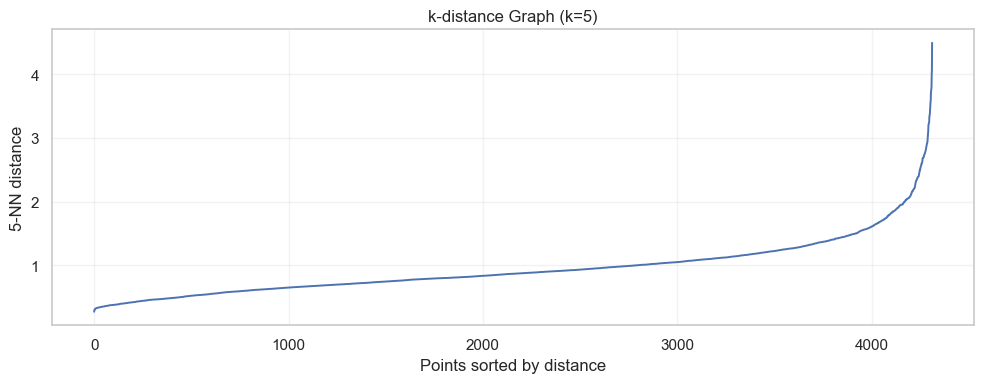

In [29]:
X_scaled = preprocess_pipeline.fit_transform(X_model)
neighbors = 5
neigh = NearestNeighbors(n_neighbors=neighbors)
nbrs = neigh.fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, neighbors - 1])

plt.figure(figsize=(10, 4))
plt.plot(k_distances, linewidth=1.4)
plt.title(f'k-distance Graph (k={neighbors})')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{neighbors}-NN distance')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

#### MODEL TRAINING

In [30]:
dbscan_eps = 2.0
dbscan_min_samples = 5
dbscan_pipeline = Pipeline(steps=[
    ('preprocess', preprocess_pipeline),
    ('dbscan', DBSCAN(eps=dbscan_eps, min_samples=dbscan_min_samples)),
])

best_dbscan_labels = dbscan_pipeline.fit_predict(X_model)
X_dbscan = dbscan_pipeline.named_steps['preprocess'].transform(X_model)

non_noise_mask = best_dbscan_labels != -1
n_clusters = len(set(best_dbscan_labels)) - (1 if -1 in best_dbscan_labels else 0)
coverage_ratio = float(non_noise_mask.mean())
noise_ratio = 1.0 - coverage_ratio

X_core = X_dbscan[non_noise_mask]
labels_core = best_dbscan_labels[non_noise_mask]
dbscan_silhouette = float(silhouette_score(X_core, labels_core))
dbscan_dbi = float(davies_bouldin_score(X_core, labels_core))
dbscan_ch = float(calinski_harabasz_score(X_core, labels_core))

best_dbscan_metrics = {
    'model': 'DBSCAN',
    'params': f'eps={dbscan_eps:.2f}, min_samples={dbscan_min_samples}',
    'clusters': int(n_clusters),
    'noise_ratio': float(noise_ratio),
    'coverage_ratio': float(coverage_ratio),
    'silhouette': dbscan_silhouette,
    'davies_bouldin': dbscan_dbi,
    'calinski_harabasz': dbscan_ch,
}

dbscan_results = pd.DataFrame([best_dbscan_metrics])
display(dbscan_results.round(4))

cluster_size = (pd.Series(best_dbscan_labels, name='Cluster').value_counts().sort_index().rename('Customers').to_frame())
cluster_size['Share_%'] = (cluster_size['Customers'] / cluster_size['Customers'].sum() * 100).round(2)
display(cluster_size)

,model,params,clusters,noise_ratio,coverage_ratio,silhouette,davies_bouldin,calinski_harabasz
0,DBSCAN,"eps=2.00, min_samples=5",3,0.0165,0.9835,0.2877,1.031,865.3568


,Customers,Share_%
Cluster,,
-1,71,1.65
0,2825,65.51
1,1411,32.72
2,5,0.12


#### PCA CLUSTER VISUALIZATION

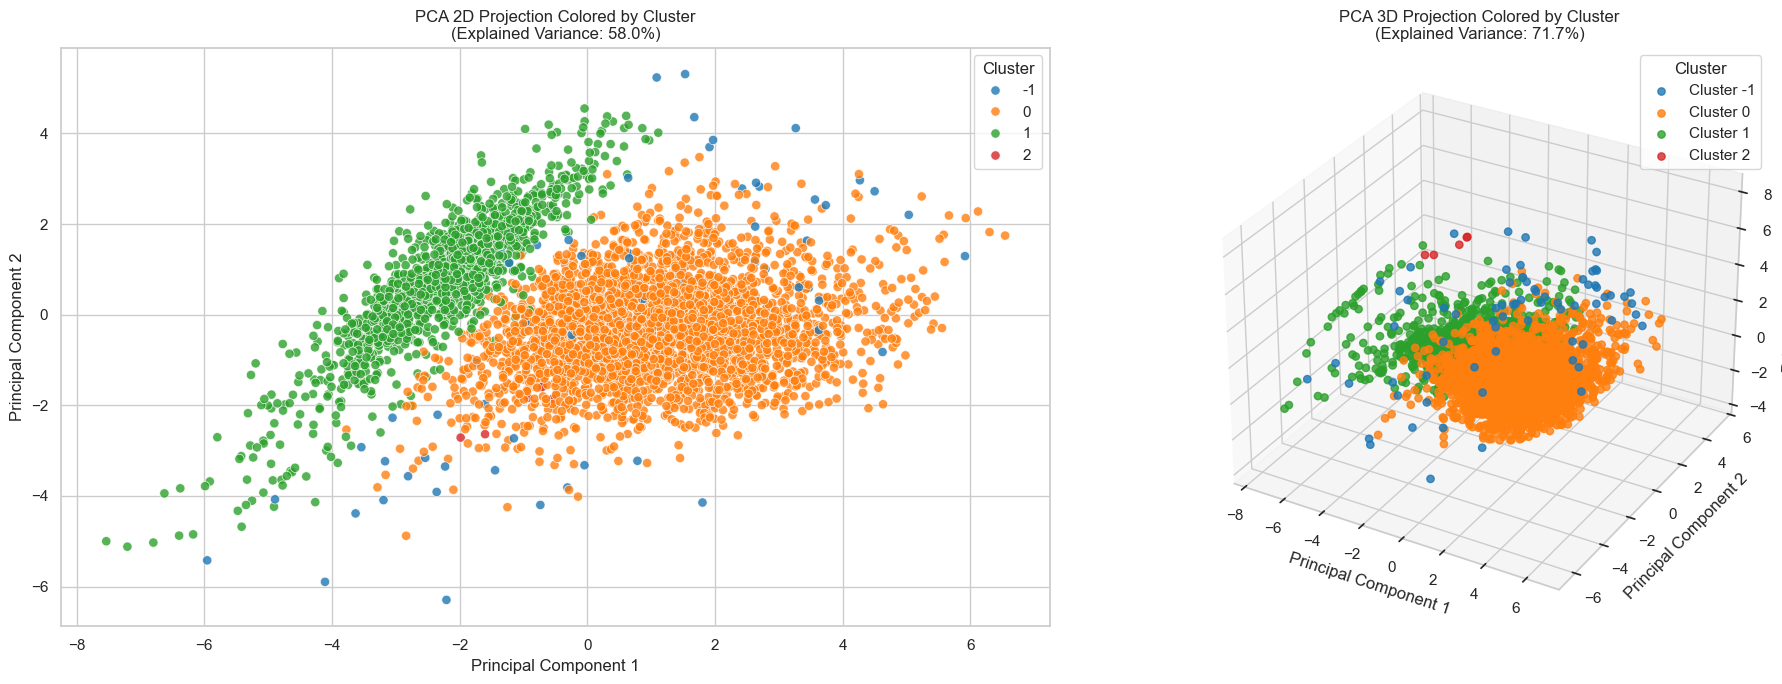

In [31]:
fig = plt.figure(figsize=(20, 7))

# ── PCA 2D ──
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_dbscan)
pca_2d_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
pca_2d_df['Cluster'] = best_dbscan_labels

ax1 = fig.add_subplot(1, 2, 1)
sns.scatterplot(
    data=pca_2d_df,
    x='PC1', y='PC2',
    hue='Cluster',
    palette='tab10',
    s=45, alpha=0.8,
    ax=ax1
)

explained_2d = pca_2d.explained_variance_ratio_.sum() * 100
ax1.set_title(f'PCA 2D Projection Colored by Cluster\n(Explained Variance: {explained_2d:.1f}%)')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
ax1.legend(title='Cluster')

# ── PCA 3D ──
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_dbscan)
pca_3d_df = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
pca_3d_df['Cluster'] = best_dbscan_labels

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
clusters_sorted = sorted(pca_3d_df['Cluster'].unique())
palette = sns.color_palette('tab10', n_colors=len(clusters_sorted))

for cl, color in zip(clusters_sorted, palette):
    subset = pca_3d_df[pca_3d_df['Cluster'] == cl]
    ax2.scatter(subset['PC1'], subset['PC2'], subset['PC3'],s=28, alpha=0.8, color=color, label=f'Cluster {cl}')

explained_3d = pca_3d.explained_variance_ratio_.sum() * 100
ax2.set_title(f'PCA 3D Projection Colored by Cluster\n(Explained Variance: {explained_3d:.1f}%)')
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')
ax2.set_zlabel('Principal Component 3')
ax2.legend(title='Cluster', loc='best')

plt.tight_layout()
plt.show()

### DBSCAN Cluster Profiling

In [32]:
dbscan_seg = cust_agg.copy()
dbscan_seg['Cluster'] = best_dbscan_labels

profile_features = [
    'TotalSpend', 'InvoiceCount', 'UniqueProducts', 'RecencyDays',
    'TenureDays', 'InvoicePerMonth', 'AverageItemPrice', 'SpendPerProduct',
    'QuantityPerInvoice', 'IsOneTransactionCustomer'
]

dbscan_profile_mean = dbscan_seg.groupby('Cluster')[profile_features].mean().round(2)
dbscan_profile_median = dbscan_seg.groupby('Cluster')[profile_features].median().round(2)

print('DBSCAN Profile — Mean of Numeric Features')
display(dbscan_profile_mean)

print('\nDBSCAN Profile — Median of Numeric Features')
display(dbscan_profile_median)

day_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
             7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

dbscan_cat_profile = dbscan_seg.groupby('Cluster').agg(
    TopCountry=('Country', lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]),
    TopDay=('MostActiveDay', lambda s: day_map.get(int(s.mode().iat[0]), s.iloc[0]) if not s.mode().empty else None),
    TopMonth=('MostActiveMonth', lambda s: month_map.get(int(s.mode().iat[0]), s.iloc[0]) if not s.mode().empty else None),
).reset_index()

print('\nDBSCAN Profile — Categorical Features (Mode per Cluster)')
display(dbscan_cat_profile)

DBSCAN Profile — Mean of Numeric Features


,TotalSpend,InvoiceCount,UniqueProducts,RecencyDays,TenureDays,InvoicePerMonth,AverageItemPrice,SpendPerProduct,QuantityPerInvoice,IsOneTransactionCustomer
Cluster,,,,,,,,,,
-1,9662.05,8.76,54.93,93.01,121.45,1.97,178.61,770.27,2746.21,0.11
0,2700.37,6.08,84.94,59.71,201.48,0.95,3.27,45.19,220.16,0.00
1,324.17,1.00,21.68,150.83,0.00,1.00,6.01,28.09,199.16,1.00
2,5255.67,2.20,1.20,142.00,0.00,2.20,2427.78,4884.62,1.00,0.00



DBSCAN Profile — Median of Numeric Features


,TotalSpend,InvoiceCount,UniqueProducts,RecencyDays,TenureDays,InvoicePerMonth,AverageItemPrice,SpendPerProduct,QuantityPerInvoice,IsOneTransactionCustomer
Cluster,,,,,,,,,,
-1,1697.85,3.0,7.0,56.0,83.0,1.20,3.59,278.99,200.0,0.0
0,1220.90,4.0,59.0,32.0,211.0,0.67,3.00,21.74,162.0,0.0
1,239.46,1.0,17.0,126.0,0.0,1.00,2.86,16.37,129.0,1.0
2,3710.50,2.0,1.0,133.0,0.0,2.00,1855.25,1855.25,1.0,0.0



DBSCAN Profile — Categorical Features (Mode per Cluster)


,Cluster,TopCountry,TopDay,TopMonth
0,-1,United Kingdom,Tue,Dec
1,0,United Kingdom,Thu,Nov
2,1,United Kingdom,Thu,Nov
3,2,United Kingdom,Fri,Mar


---
## DBSCAN Cluster Interpretation

### Cluster 0 — Established High-Value Regulars
- **Profile:** Largest segment (2,825 customers), multi-transaction buyers with long tenure and relatively recent activity.
- **Defining traits:** High `TotalSpend`, highest `InvoiceCount`/`UniqueProducts` among stable clusters, moderate `RecencyDays`.
- **Suggested action:** Retention offers, cross-sell, and loyalty rewards to maintain frequency.

### Cluster 1 — One-Time Low-Value Lapsed
- **Profile:** One-off purchasers with low spend and long inactivity (1,411 customers).
- **Defining traits:** `InvoiceCount` = 1, `IsOneTransactionCustomer` = 1.0, low `TotalSpend`, high `RecencyDays`, zero `TenureDays`.
- **Suggested action:** Win-back campaigns and second-order incentives.

### Cluster 2 — Premium Single-Item Outliers
- **Profile:** Very small cluster (5 customers) with extremely high item prices but minimal quantities.
- **Defining traits:** Huge `AverageItemPrice` and `SpendPerProduct`, `UniqueProducts` ≈ 1, `QuantityPerInvoice` ≈ 1, low tenure.
- **Suggested action:** Manual review or white-glove service; treat separately from main marketing flows.

### Noise (Cluster -1) — Irregular/Outlier Behavior
- **Profile:** Mixed behaviors (71 customers) that do not fit stable clusters.
- **Defining traits:** Very high mean `QuantityPerInvoice` and `TotalSpend`, but medians are much lower, indicating extreme outliers.
- **Suggested action:** Keep separate for anomaly monitoring and investigation.

---

---
## 10. K-Means VS DBSCAN —— Select best model
Although DBSCAN achieved better clustering metrics than K-Means, it was not selected as the final model.

From a quantitative perspective, DBSCAN outperformed K-Means:

- Silhouette Score: 0.287 vs 0.228
- Davies-Bouldin Index: 1031 vs 1509
- calinski-harabasz : 865 vs 1069
- Coverage Ratio: 98.35% (only 1.65% noise)

This indicates better cluster separation.

However, from a business perspective, **DBSCAN** produced only 3 clusters + noise, and one of those clusters contained just 5 customers. Such a small group cannot be considered a reliable standalone customer segment and is better treated as outliers or special cases.

In contrast, **K-Means** generated 5 clearer and more balanced customer segments, making the results easier to interpret and more useful for marketing, retention, and personalization strategies.

## Final Decision

**K-Means** was selected as the final model because it provides more practical and actionable customer segmentation, while still maintaining reasonably close overall performance to DBSCAN

---
## 11. Save Best Model —— K-Means

In [33]:
artifacts = {
    "model_pipeline":    kmeans_pipeline,
    "selected_features": selected_features,
    "model_log_features": model_log_features,
    "caps": caps,
    "k": k
}
joblib.dump(artifacts, "../model/customer_segmentation_artifacts.joblib")

['../model/customer_segmentation_artifacts.joblib']

---
# DONE